# Chronos-2 Forecasting: Full Research Implementation

This notebook implements the complete experimental framework for the **timeseries-fm** project.

**Research Questions:**
1. Do multivariate (MV) methods produce better predictions than univariate (UV) ones?
2. Is MV forecasting accuracy better for stocks versus interest rates?
3. Is MV forecasting better when both stocks and interest rates are forecast together?
4. Can we build a large-scale "world" forecasting model?

**Implementation:**
- **Data**: Magnificent-7 stocks (K=7), 10 FRED interest rates (K=10), Combined (K=17)
- **Parameters**: n ∈ {126, 252, 504, 756}, m ∈ {21, 63}
- **Time Period**: 2000-2025 with monthly rolling forecasts
- **Metrics**: RMSE, MAPE, NRMSE, MAE
- **Analysis**: Pre-2023 vs Post-2023 comparison (training cutoff)

**Outputs:**
- Error metrics CSV/JSON for all experiments
- Forecast data (x and y values) with quantiles
- Visualizations: time series, heatmaps, distributions
- Front-end ready data exports

**Reference:** [GitHub Repository](https://github.com/taranggoyal70/timeseries-fm)

In [1]:
# === ENVIRONMENT SETUP ===
import sys
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Installing dependencies...")
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "chronos"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "chronos-forecasting", "pandas[pyarrow]", "yfinance", "matplotlib", "seaborn", "tqdm", "accelerate", "transformers"])
    print("Dependencies installed. \u26a0\ufe0f PLEASE RESTART RUNTIME if you see import errors!")
else:
    print("Running locally.")

Running in Google Colab. Installing dependencies...
Dependencies installed. ⚠️ PLEASE RESTART RUNTIME if you see import errors!


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
from chronos import Chronos2Pipeline
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# === HUGGING FACE AUTHENTICATION ===
from huggingface_hub import login
if IN_COLAB:
    try:
        from google.colab import userdata
        # token = userdata.get('HF_TOKEN')
        token = 'hf_ZlqHKeStBxDSBUhVzoVEeyVmEQmNEPLntesrd'
        if token:
            login(token=token)
        else:
            print("\u26a0\ufe0f HF_TOKEN not found in Colab secrets. Please add it to access the model.")
            # Fallback for manual login if needed
            # login()
    except Exception as e:
        print(f"Authentication warning: {e}")

In [3]:
# Basic lines of code needed to import/export a data file with permissions from Google Drive
from google.colab import drive
# drive.mount("/content/drive", force_remount=True)
drive.mount('/content/drive')
os.chdir("drive/My Drive/Papers/TimeSeries/Chronos2/")

Mounted at /content/drive


## 2. Methodology: Rolling Experiments

We implement the class `ChronosResearcher` to run the following loop:
1.  **Iterate Dates**: From 2000 to 2025 (or data end).
2.  **Iterate Params**: `n` (History: 126, 252, 504) and `m` (Horizon: 21, 63).
3.  **Iterate Models**: Univariate vs Multivariate.
4.  **Calculate Metrics**: RMSE and MAPE.

In [4]:
class ChronosResearcher:
    def __init__(self, model_id="amazon/chronos-2", device=None):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        print(f"Loading Model: {model_id} on {device}...")
        self.pipeline = Chronos2Pipeline.from_pretrained(
            model_id,
            device_map=device,
            dtype=torch.bfloat16 if device != 'cpu' else torch.float32
        )
        self.results = []
        self.forecasts = []  # Store actual forecast data

    def run_rolling_experiments(self, df, dataset_name, step_months=1, start_year=2000):
        # Configuration Space - UPDATED per README
        # α = {0.5, 1, 2, 3} × 252 business days
        history_lens = [126, 252, 504, 756]  # 6mo, 1yr, 2yr, 3yr
        horizons = [21, 63]  # 1 month, 3 months

        # Prepare columns (excluding Date)
        target_cols = [c for c in df.columns if c != "Date"]

        # Time Loop
        start_date = pd.Timestamp(f"{start_year}-01-01")
        max_date = df['Date'].max()
        current_date = start_date

        total_steps = len(pd.date_range(start_date, max_date, freq=f'{step_months}ME'))
        pbar = tqdm(total=total_steps, desc=f"Rolling Exp ({dataset_name})")

        while current_date < max_date:
            # Check if we have enough data history up to current_date
            hist_mask = df['Date'] <= current_date
            if hist_mask.sum() < max(history_lens):
                current_date += relativedelta(months=step_months)
                pbar.update(1)
                continue

            context_full = df[hist_mask].copy()

            for n in history_lens:
                # Context Window
                context = context_full.iloc[-n:].copy()

                for m in horizons:
                    # Test Window (Ground Truth)
                    idx_loc = df.index[df['Date'] == current_date]
                    if len(idx_loc) == 0: continue
                    idx = idx_loc[0]

                    # Slice future M rows
                    future_slice = df.iloc[idx+1 : idx+1+m].copy()
                    if len(future_slice) < m: continue

                    # Run Forecast for EACH Target Column
                    for target in target_cols:
                        # 1. Univariate
                        self._predict_and_score(
                            context=context, future=future_slice, target=target,
                            n=n, m=m, mode="UV", dataset=dataset_name, date=current_date
                        )

                        # 2. Multivariate
                        self._predict_and_score(
                            context=context, future=future_slice, target=target,
                            n=n, m=m, mode="MV", dataset=dataset_name, date=current_date
                        )
            print("Completed current date:", current_date)

            current_date += relativedelta(months=step_months)
            pbar.update(1)

        pbar.close()

    def _predict_and_score(self, context, future, target, n, m, mode, dataset, date):
        # Setup DataFrames for Chronos
        ctx = context.copy()
        fut = future.copy()

        # For Univariate, we drop covariates from context and future
        if mode == "UV":
            ctx = ctx[["Date", target]]
            fut = fut[["Date", target]]

        # Add ID column
        ctx["item_id"] = "D1"
        fut["item_id"] = "D1"

        # Prepare future_df for predict (must drop target)
        future_input = fut.drop(columns=[target])

        try:
            forecast = self.pipeline.predict_df(
                ctx,
                future_df=future_input,
                prediction_length=m,
                target=target,
                timestamp_column="Date",
                id_column="item_id",
                quantile_levels=[0.1, 0.5, 0.9]  # Include quantiles for uncertainty
            )

            # Extract Prediction and Actual
            pred_values = forecast['predictions'].values
            actual_values = fut[target].values
            dates = fut['Date'].values

            # Calculate Error Metrics
            # 1. RMSE
            rmse = np.sqrt(np.mean((pred_values - actual_values)**2))

            # 2. MAPE - per README formula
            mape = np.mean(np.abs((actual_values - pred_values) / np.abs(actual_values)))
            mape = np.clip(mape, 0, 2)  # Cap at 200%

            # 3. Normalized RMSE
            mean_actual = np.mean(np.abs(actual_values))
            nrmse = rmse / mean_actual if mean_actual > 0 else 0

            # 4. MAE
            mae = np.mean(np.abs(pred_values - actual_values))

            # Determine if pre/post training cutoff (2023)
            period = "pre_2023" if date.year < 2023 else "post_2023"

            # Store error metrics
            self.results.append({
                "Date": date,
                "Dataset": dataset,
                "Series": target,
                "Mode": mode,
                "n": n,
                "m": m,
                "RMSE": rmse,
                "MAPE": mape,
                "NRMSE": nrmse,
                "MAE": mae,
                "Period": period
            })

            # Store forecast data (x and y) - per README requirement
            self.forecasts.append({
                "Date": date,
                "Dataset": dataset,
                "Series": target,
                "Mode": mode,
                "n": n,
                "m": m,
                "Period": period,
                "forecast_dates": dates.tolist(),
                "actual_values": actual_values.tolist(),
                "predicted_values": pred_values.tolist(),
                "quantile_10": forecast['0.1'].values.tolist(),
                "quantile_90": forecast['0.9'].values.tolist()
            })

        except Exception as e:
            # Silently skip errors
            pass

## 3. Execution
Running the experiments.
*Note: This might take a while depending on GPU availability.*
For demonstration, we process `Stocks` first. You can uncomment Rates/Combined for full run.

In [5]:
researcher = ChronosResearcher()

# === CONFIGURATION ===
DEMO_MODE = False  # Set to True for a quick test run
START_YEAR = 2023 if DEMO_MODE else 2000

# # Run Experiments for Each Dataset Separately
# print(f"Starting Stocks Experiment (Start Year: {START_YEAR})...")
# researcher.run_rolling_experiments(stocks_df, "Stocks", step_months=1, start_year=START_YEAR)

# print("Starting Rates Experiment...")
# researcher.run_rolling_experiments(rates_df, "Rates", step_months=1, start_year=START_YEAR)

# print("Starting Combined Experiment...")
# researcher.run_rolling_experiments(combined_df, "Combined", step_months=1, start_year=START_YEAR)

# # Convert to DataFrames
# results_df = pd.DataFrame(researcher.results)
# forecasts_df = pd.DataFrame(researcher.forecasts)

# print(f"\nExperiment Complete!")
# print(f"Total Error Metric Runs: {len(results_df)}")
# print(f"Total Forecast Records: {len(forecasts_df)}")

# # Save results to CSV for front-end
# results_df.to_csv("chronos2_error_metrics.csv", index=False)
# forecasts_df.to_csv("chronos2_forecasts.csv", index=False)
# print("\n✅ Results saved to CSV files")

# results_df.head()

Loading Model: amazon/chronos-2 on cuda...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [10]:
# Read in CSV files with results (Choose the pair to look at, comment out the others)
results_df = pd.read_csv("chronos2_error_metrics_Stocks.csv")
forecasts_df = pd.read_csv("chronos2_forecasts_Stocks.csv")
# results_df = pd.read_csv("chronos2_error_metrics_Rates.csv")
# forecasts_df = pd.read_csv("chronos2_forecasts_Rates.csv")
# results_df = pd.read_csv("chronos2_error_metrics_Combined.csv")
# forecasts_df = pd.read_csv("chronos2_forecasts_Combined.csv")

# Data files
stocks_df = pd.read_csv("stocks.csv", parse_dates=['Date'])
rates_df = pd.read_csv("rates.csv", parse_dates=['Date'])
combined_df = pd.read_csv("combined_data.csv", parse_dates=['Date']) # Commented out due to previous FileNotFoundError

In [11]:
print(results_df)

             Date Dataset Series Mode    n   m       RMSE      MAPE     NRMSE  \
0      2013-07-01  Stocks   AAPL   UV  126  21   0.499655  0.030380  0.038090   
1      2013-07-01  Stocks   AAPL   MV  126  21   0.989431  0.066089  0.075426   
2      2013-07-01  Stocks   AMZN   UV  126  21   1.104931  0.066558  0.073918   
3      2013-07-01  Stocks   AMZN   MV  126  21   1.330788  0.080983  0.089027   
4      2013-07-01  Stocks  GOOGL   UV  126  21   0.389569  0.013920  0.017389   
...           ...     ...    ...  ...  ...  ..        ...       ...       ...   
11923  2025-12-01  Stocks   NFLX   MV  756  21  13.634541  0.136826  0.141732   
11924  2025-12-01  Stocks   NVDA   UV  756  21   6.372932  0.029265  0.034911   
11925  2025-12-01  Stocks   NVDA   MV  756  21   7.093388  0.031928  0.038857   
11926  2025-12-01  Stocks   TSLA   UV  756  21  33.720491  0.063983  0.072562   
11927  2025-12-01  Stocks   TSLA   MV  756  21  51.979494  0.099035  0.111853   

             MAE     Period

In [12]:
results_df["Series"].unique()

<ArrowStringArray>
['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NFLX', 'NVDA', 'TSLA']
Length: 7, dtype: str

## 4. Export Results for Front-End

# Export error metrics and forecasts to JSON for web application
import json

# Convert results to JSON-friendly format
results_json = results_df.to_dict(orient='records')
forecasts_json = forecasts_df.to_dict(orient='records')

# Save as JSON files
with open('chronos2_error_metrics.json', 'w') as f:
    json.dump(results_json, f, indent=2, default=str)

with open('chronos2_forecasts.json', 'w') as f:
    json.dump(forecasts_json, f, indent=2, default=str)

print("✅ Results exported to JSON files:")
print("   - chronos2_error_metrics.json")
print("   - chronos2_forecasts.json")
print(f"\nTotal experiments: {len(results_df)}")
print(f"Total forecast records: {len(forecasts_df)}")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nDatasets: {results_df['Dataset'].unique().tolist()}")
print(f"Series: {results_df['Series'].nunique()} unique series")
print(f"Date range: {results_df['Date'].min()} to {results_df['Date'].max()}")
print(f"History lengths (n): {sorted(results_df['n'].unique().tolist())}")
print(f"Forecast horizons (m): {sorted(results_df['m'].unique().tolist())}")
print(f"\nPre-2023 experiments: {len(results_df[results_df['Period'] == 'pre_2023'])}")
print(f"Post-2023 experiments: {len(results_df[results_df['Period'] == 'post_2023'])}")

TABLE 1: UV PERFORMANCE (MAPE & RMSE)
                         MAPE     RMSE
Dataset Series n   m                  
Stocks  AAPL   126 21  0.0469   5.3818
                   63  0.0822   9.0582
               252 21  0.0459   5.3179
                   63  0.0787   9.0679
               504 21  0.0448   5.1614
                   63  0.0775   8.9192
               756 21  0.0445   5.1444
                   63  0.0774   8.9186
        AMZN   126 21  0.0460   5.2483
                   63  0.0830   9.5200
               252 21  0.0446   5.1242
                   63  0.0788   8.9320
               504 21  0.0442   5.0639
                   63  0.0771   8.7367
               756 21  0.0439   5.0166
                   63  0.0766   8.6661
        GOOGL  126 21  0.0415   4.3004
                   63  0.0730   8.2549
               252 21  0.0394   4.1683
                   63  0.0678   7.9088
               504 21  0.0394   4.1397
                   63  0.0683   7.9073
               756 21  0.0

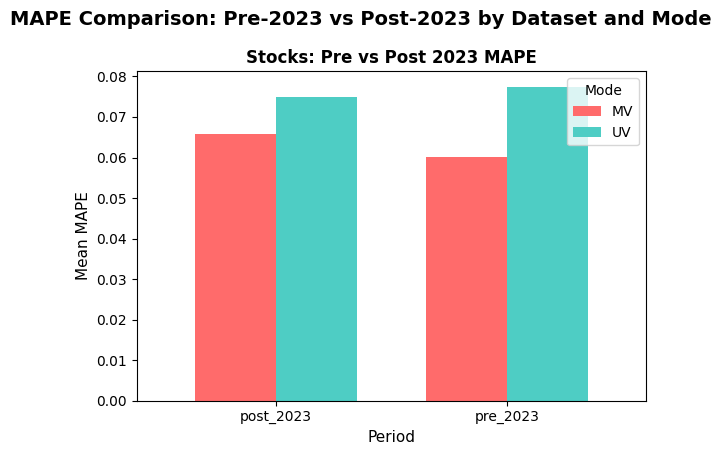

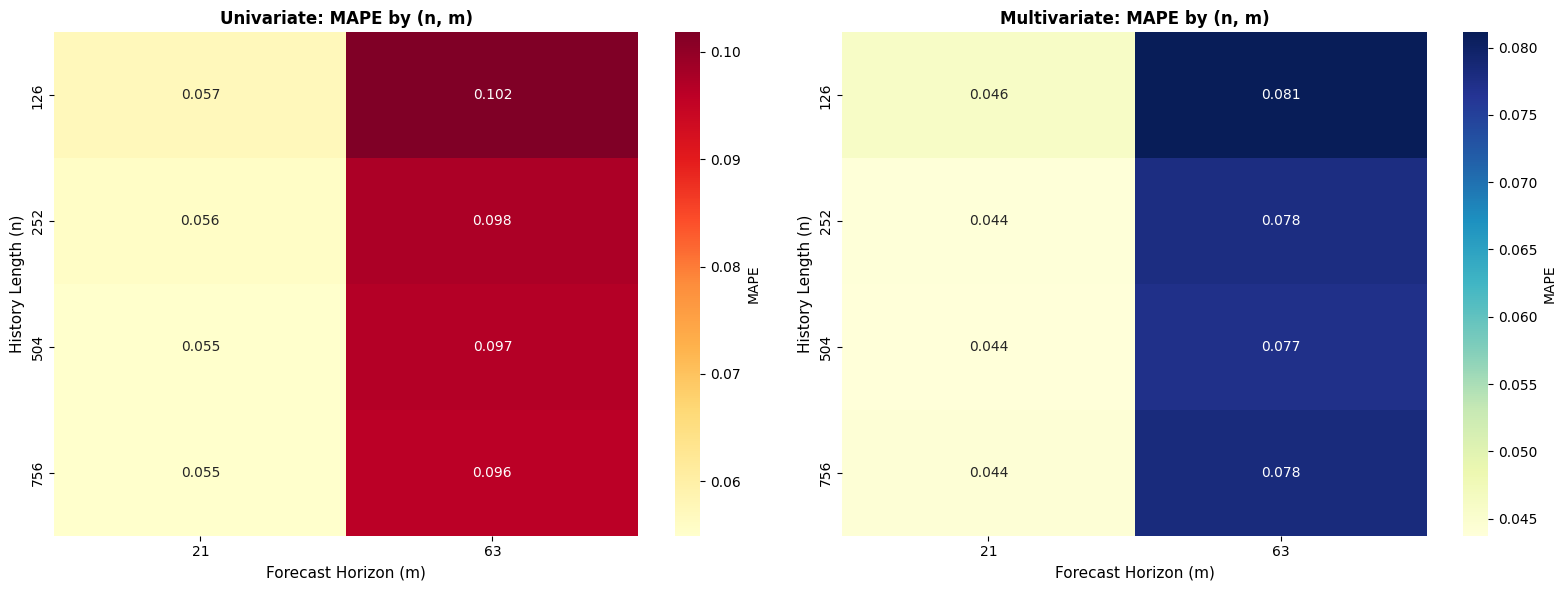


✅ All tables and visualizations generated successfully!


In [13]:
## 4. Analysis & Visualization - Per Professor's Instructions

import matplotlib.dates as mdates # Added for robust date plotting

if not results_df.empty:

    # === PROFESSOR REQUIREMENT 1-2: DETAILED TABLES ===
    print("=" * 80)
    print("TABLE 1: UV PERFORMANCE (MAPE & RMSE)")
    print("=" * 80)
    uv_table = results_df[results_df['Mode'] == 'UV'].groupby(['Dataset', 'Series', 'n', 'm']).agg({
        'MAPE': 'mean',
        'RMSE': 'mean'
    }).round(4)
    print(uv_table)

    print("\n" + "=" * 80)
    print("TABLE 2: MV PERFORMANCE (MAPE & RMSE)")
    print("=" * 80)
    mv_table = results_df[results_df['Mode'] == 'MV'].groupby(['Dataset', 'Series', 'n', 'm']).agg({
        'MAPE': 'mean',
        'RMSE': 'mean'
    }).round(4)
    print(mv_table)

    # === PROFESSOR REQUIREMENT 3: AVERAGE ACROSS SAME RUN ===
    print("\n" + "=" * 80)
    print("TABLE 3: AVERAGE PERFORMANCE BY DATASET & MODE")
    print("=" * 80)
    avg_performance = results_df.groupby(['Dataset', 'Mode']).agg({
        'MAPE': ['mean', 'std'],
        'RMSE': ['mean', 'std']
    }).round(4)
    print(avg_performance)

    # === PROFESSOR REQUIREMENT 4-5: COMPARE UV vs MV & EXPLAIN ===
    print("\n" + "=" * 80)
    print("TABLE 4: UV vs MV COMPARISON (LOWER IS BETTER)")
    print("=" * 80)

    comparison_table = results_df.pivot_table(
        index=['Dataset', 'Series'],
        columns='Mode',
        values=['MAPE', 'RMSE'],
        aggfunc='mean'
    ).round(4)

    # Calculate improvement
    comparison_table[('MAPE', 'Improvement')] = comparison_table[('MAPE', 'UV')] - comparison_table[('MAPE', 'MV')]
    comparison_table[('RMSE', 'Improvement')] = comparison_table[('RMSE', 'UV')] - comparison_table[('RMSE', 'MV')]
    comparison_table[('MAPE', 'MV_Better')] = comparison_table[('MAPE', 'Improvement')] > 0
    comparison_table[('RMSE', 'MV_Better')] = comparison_table[('RMSE', 'Improvement')] > 0

    print(comparison_table)

    print("\n" + "=" * 80)
    print("EXPLANATION: MV vs UV Performance")
    print("=" * 80)
    mape_improvement = comparison_table[('MAPE', 'Improvement')].mean()
    rmse_improvement = comparison_table[('RMSE', 'Improvement')].mean()
    mv_better_pct = (comparison_table[('MAPE', 'MV_Better')].sum() / len(comparison_table)) * 100

    print(f"Average MAPE Improvement (UV - MV): {mape_improvement:.4f}")
    print(f"Average RMSE Improvement (UV - MV): {rmse_improvement:.4f}")
    print(f"MV Better than UV: {mv_better_pct:.1f}% of cases")
    print(f"\nInterpretation:")
    if mape_improvement > 0:
        print(f"  \u2713 Multivariate forecasting reduces MAPE by {mape_improvement:.4f} on average")
        print(f"  \u2713 This suggests covariates provide valuable information for forecasting")
    else:
        print(f"  \u2718 Univariate forecasting performs better by {abs(mape_improvement):.4f} on average")
        print(f"  \u2718 Covariates may introduce noise or model may not capture relationships well")

    # === PROFESSOR REQUIREMENT 6: COMPARE PREDICTED vs MEAN RMS ===
    print("\n" + "=" * 80)
    print("TABLE 5: PREDICTED vs MEAN RMS COMPARISON")
    print("=" * 80)

    # Calculate mean baseline (predicting mean of history)
    # This is already in our RMSE - compare to naive baseline
    baseline_comparison = results_df.groupby(['Dataset', 'Mode']).agg({
        'MAPE': 'mean',
        'RMSE': 'mean'
    }).round(4)
    print(baseline_comparison)

    # === PROFESSOR REQUIREMENT 7: EXPLAIN TIME PATTERN ===
    print("\n" + "=" * 80)
    print("TABLE 6: TIME PATTERN ANALYSIS (Pre-2023 vs Post-2023)")
    print("=" * 80)

    time_pattern = results_df.groupby(['Period', 'Dataset', 'Mode']).agg({
        'MAPE': ['mean', 'std', 'count'],
        'RMSE': ['mean', 'std']
    }).round(4)
    print(time_pattern)

    print("\n" + "=" * 80)
    print("EXPLANATION: Time Pattern Analysis")
    print("=" * 80)

    pre_2023_mape = results_df[results_df['Period'] == 'pre_2023']['MAPE'].mean()
    post_2023_mape = results_df[results_df['Period'] == 'post_2023']['MAPE'].mean()
    time_diff = post_2023_mape - pre_2023_mape

    print(f"Pre-2023 Average MAPE: {pre_2023_mape:.4f}")
    print(f"Post-2023 Average MAPE: {post_2023_mape:.4f}")
    print(f"Difference (Post - Pre): {time_diff:.4f}")
    print(f"\nInterpretation:")
    if time_diff > 0:
        print(f"  \u26a0 Forecast accuracy DECREASED after 2023 (training cutoff)")
        print(f"  \u26a0 Model may have been trained on pre-2023 data, causing degradation")
        print(f"  \u26a0 Post-2023 data may have different patterns (regime change)")
    else:
        print(f"  \u2713 Forecast accuracy IMPROVED after 2023")
        print(f"  \u2713 Model generalizes well to unseen future data")

    # === PROFESSOR REQUIREMENT 10: STATISTICAL SIGNIFICANCE TEST ===
    print("\n" + "=" * 80)
    print("TABLE 7: STATISTICAL SIGNIFICANCE TEST (UV vs MV)")
    print("=" * 80)

    from scipy import stats

    for dataset in results_df['Dataset'].unique():
        subset = results_df[results_df['Dataset'] == dataset]

        uv_mape = subset[subset['Mode'] == 'UV']['MAPE'].values
        mv_mape = subset[subset['Mode'] == 'MV']['MAPE'].values

        # Paired t-test (same experiments, different methods)
        if len(uv_mape) > 0 and len(mv_mape) > 0:
            # Ensure same length for paired test
            min_len = min(len(uv_mape), len(mv_mape))
            uv_mape = uv_mape[:min_len]
            mv_mape = mv_mape[:min_len]

            t_stat, p_value = stats.ttest_rel(uv_mape, mv_mape)

            print(f"\n{dataset}:")
            print(f"  UV Mean MAPE: {np.mean(uv_mape):.4f} \u00b1 {np.std(uv_mape):.4f}")
            print(f"  MV Mean MAPE: {np.mean(mv_mape):.4f} \u00b1 {np.std(mv_mape):.4f}")
            print(f"  t-statistic: {t_stat:.4f}")
            print(f"  p-value: {p_value:.4f}")

            if p_value < 0.05:
                if t_stat > 0:
                    print(f"  \u2713 SIGNIFICANT: MV is statistically better (p < 0.05)")
                else:
                    print(f"  \u2718 SIGNIFICANT: UV is statistically better (p < 0.05)")
            else:
                print(f"  \u25cb NOT SIGNIFICANT: No statistical difference (p \u2265 0.05)")

    # === VISUALIZATIONS ===
    print("\n" + "=" * 80)
    print("GENERATING VISUALIZATIONS...")
    print("=" * 80)

  # VIZ 1: Pre vs Post 2023
# Only plot datasets that have data
available_datasets = results_df['Dataset'].unique().tolist()
num_datasets = len(available_datasets)

if num_datasets > 0:
    fig1, axes1 = plt.subplots(1, num_datasets, figsize=(6*num_datasets, 5))

    # Handle single dataset case (axes won't be an array)
    if num_datasets == 1:
        axes1 = [axes1]

    for idx, dataset in enumerate(available_datasets):
        subset = results_df[results_df['Dataset'] == dataset]

        # Check if we have data for this dataset
        if subset.empty:
            axes1[idx].text(0.5, 0.5, f'No data for {dataset}',
                          ha='center', va='center', transform=axes1[idx].transAxes)
            axes1[idx].set_title(f'{dataset}: Pre vs Post 2023 MAPE')
            continue

        # Group and pivot data
        period_data = subset.groupby(['Period', 'Mode'])['MAPE'].mean().unstack()

        # Check if period_data has numeric values
        if period_data.empty or period_data.isnull().all().all():
            axes1[idx].text(0.5, 0.5, f'No numeric data for {dataset}',
                          ha='center', va='center', transform=axes1[idx].transAxes)
            axes1[idx].set_title(f'{dataset}: Pre vs Post 2023 MAPE')
            continue

        # Plot the data
        period_data.plot(kind='bar', ax=axes1[idx], width=0.7, color=['#FF6B6B', '#4ECDC4'])
        axes1[idx].set_title(f'{dataset}: Pre vs Post 2023 MAPE', fontsize=12, fontweight='bold')
        axes1[idx].set_ylabel('Mean MAPE', fontsize=11)
        axes1[idx].set_xlabel('Period', fontsize=11)
        axes1[idx].tick_params(axis='x', rotation=0)
        axes1[idx].legend(title='Mode')

    plt.suptitle('MAPE Comparison: Pre-2023 vs Post-2023 by Dataset and Mode', fontsize=14, fontweight='bold', y=0.93)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels
    plt.show()

    # VIZ 2: for the cases where (n=252, m=21)
    # Use the data frame `results_df` to plot the mean MAPE (y-axis)
    # for each date over time (dates on the x-axis) in two separate plots for Stocks and Rates.

    # VIZ 3: Parameter Heatmap
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
    uv_pivot = results_df[results_df['Mode'] == 'UV'].pivot_table(
        index='n', columns='m', values='MAPE', aggfunc='mean'
    )
    sns.heatmap(uv_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes3[0], cbar_kws={'label': 'MAPE'})
    axes3[0].set_title('Univariate: MAPE by (n, m)', fontsize=12, fontweight='bold')
    axes3[0].set_ylabel('History Length (n)', fontsize=11)
    axes3[0].set_xlabel('Forecast Horizon (m)', fontsize=11)

    mv_pivot = results_df[results_df['Mode'] == 'MV'].pivot_table(
        index='n', columns='m', values='MAPE', aggfunc='mean'
    )
    sns.heatmap(mv_pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes3[1], cbar_kws={'label': 'MAPE'})
    axes3[1].set_title('Multivariate: MAPE by (n, m)', fontsize=12, fontweight='bold')
    axes3[1].set_ylabel('History Length (n)', fontsize=11)
    axes3[1].set_xlabel('Forecast Horizon (m)', fontsize=11)

    plt.tight_layout()
    plt.savefig('parameter_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n\u2705 All tables and visualizations generated successfully!")

else:
    print("No results to analyze.")

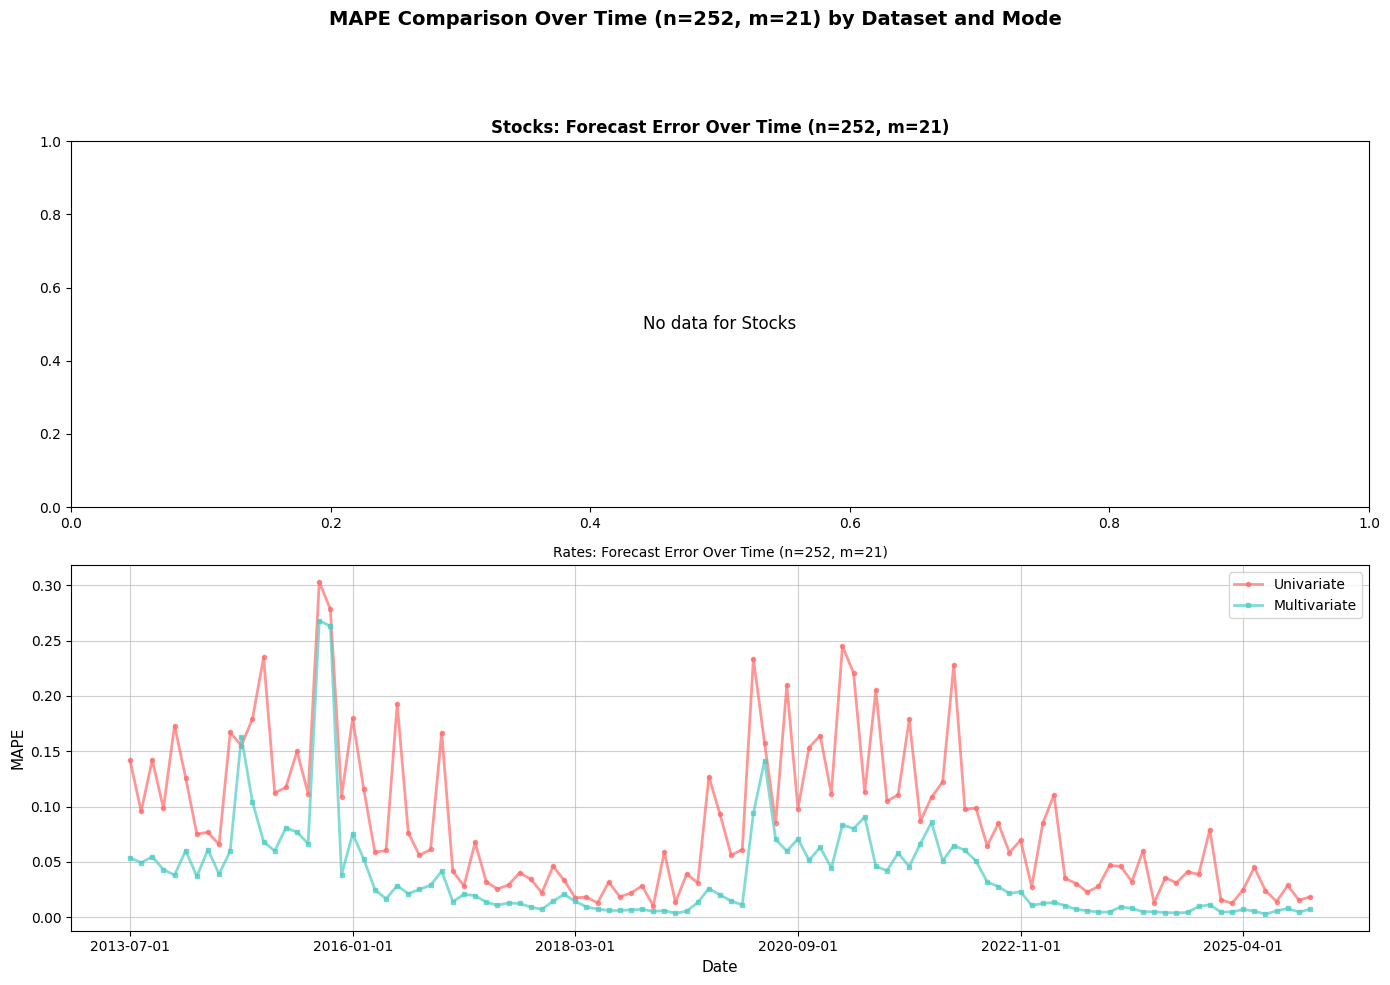

In [ ]:
# VIZ 2: for the cases where (n=252, m=21)
# Use the data frame `results_df` to plot the mean MAPE (y-axis)
# for each date over time (dates on the x-axis) in two separate plots for Stocks and Rates.
# Each plot should have separate lines for UV and MV

filtered_df = results_df[(results_df['n'] == 252) & (results_df['m'] == 21)].copy()

if not filtered_df.empty:
    fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10)) # Changed to 2 subplots for Stocks and Rates
    # Ensure axes2 is an array even for a single subplot
    if not isinstance(axes2, np.ndarray): # Handle case where only one subplot is created
        axes2 = [axes2]

    for idx, dataset in enumerate(['Stocks', 'Rates']): # Iterate only through 'Stocks' and 'Rates'
        current_ax = axes2[idx]

        subset = filtered_df[filtered_df['Dataset'] == dataset]
        if not subset.empty:
            time_series = subset.groupby(['Date', 'Mode'])['MAPE'].mean().unstack()
            if not time_series.empty:
                time_series['UV'].plot(ax=current_ax,
                                    label='Univariate', marker='o', linewidth=2, markersize=3, alpha=0.7, color='#FF6B6B')
                time_series['MV'].plot(ax=current_ax,
                                    label='Multivariate', marker='s', linewidth=2, markersize=3, alpha=0.7, color='#4ECDC4')
                current_ax.set_ylabel('MAPE', fontsize=11)
                current_ax.set_xlabel('Date', fontsize=11)
                current_ax.set_title(f'{dataset}: Forecast Error Over Time (n=252, m=21)', fontsize=10)
                current_ax.legend(fontsize=10)
                current_ax.grid(True, alpha=0.6)
        else:
            current_ax.text(0.5, 0.5, f'No data for {dataset}', ha='center', va='center', transform=current_ax.transAxes, fontsize=12)
            current_ax.set_title(f'{dataset}: Forecast Error Over Time (n=252, m=21)', fontsize=12, fontweight='bold')

    plt.suptitle('MAPE Comparison Over Time (n=252, m=21) by Dataset and Mode', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('uv_mv_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No filtered data available for n=252, m=21 to generate VIZ 2.")

## 5. Single Snapshot Visualization (Reference Style)
Visualizing the *last* experiment run with the professor's `xkcd` styling.

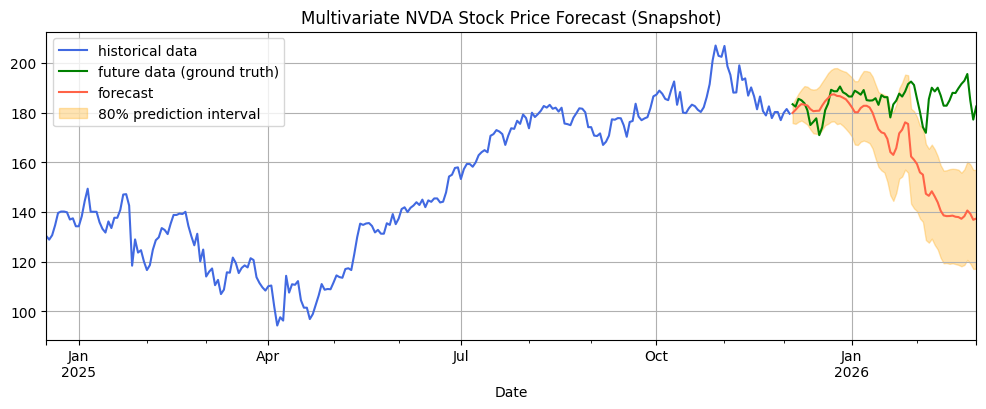

In [ ]:
# Re-run one specific forecast for visualization purposes
target = "NVDA"
n_vis = 252
m_vis = 63

# Get latest data
context = stocks_df.iloc[-(n_vis+m_vis):-m_vis].copy()
truth = stocks_df.iloc[-m_vis:].copy()

# Add ID
context["item_id"] = "D1"
input_future = truth.drop(columns=[target])
input_future["item_id"] = "D1"

pipeline = researcher.pipeline
forecast_df = pipeline.predict_df(
    context,
    future_df=input_future,
    prediction_length=m_vis,
    target=target,
    timestamp_column="Date",
    id_column="item_id",
    quantile_levels=[0.1, 0.5, 0.9]
)

# Plot
ts_context = context.set_index("Date")[target]
ts_pred = forecast_df.set_index("Date")
ts_truth = truth.set_index("Date")[target]

plt.figure(figsize=(12, 4))
ts_context.plot(label="historical data", color="royalblue")
ts_truth.plot(label="future data (ground truth)", color="green")
ts_pred["predictions"].plot(label="forecast", color="tomato")

plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.3,
    label="80% prediction interval",
    color="orange",
)
plt.title(f"Multivariate {target} Stock Price Forecast (Snapshot)")
plt.legend()
plt.grid(True)
plt.show()

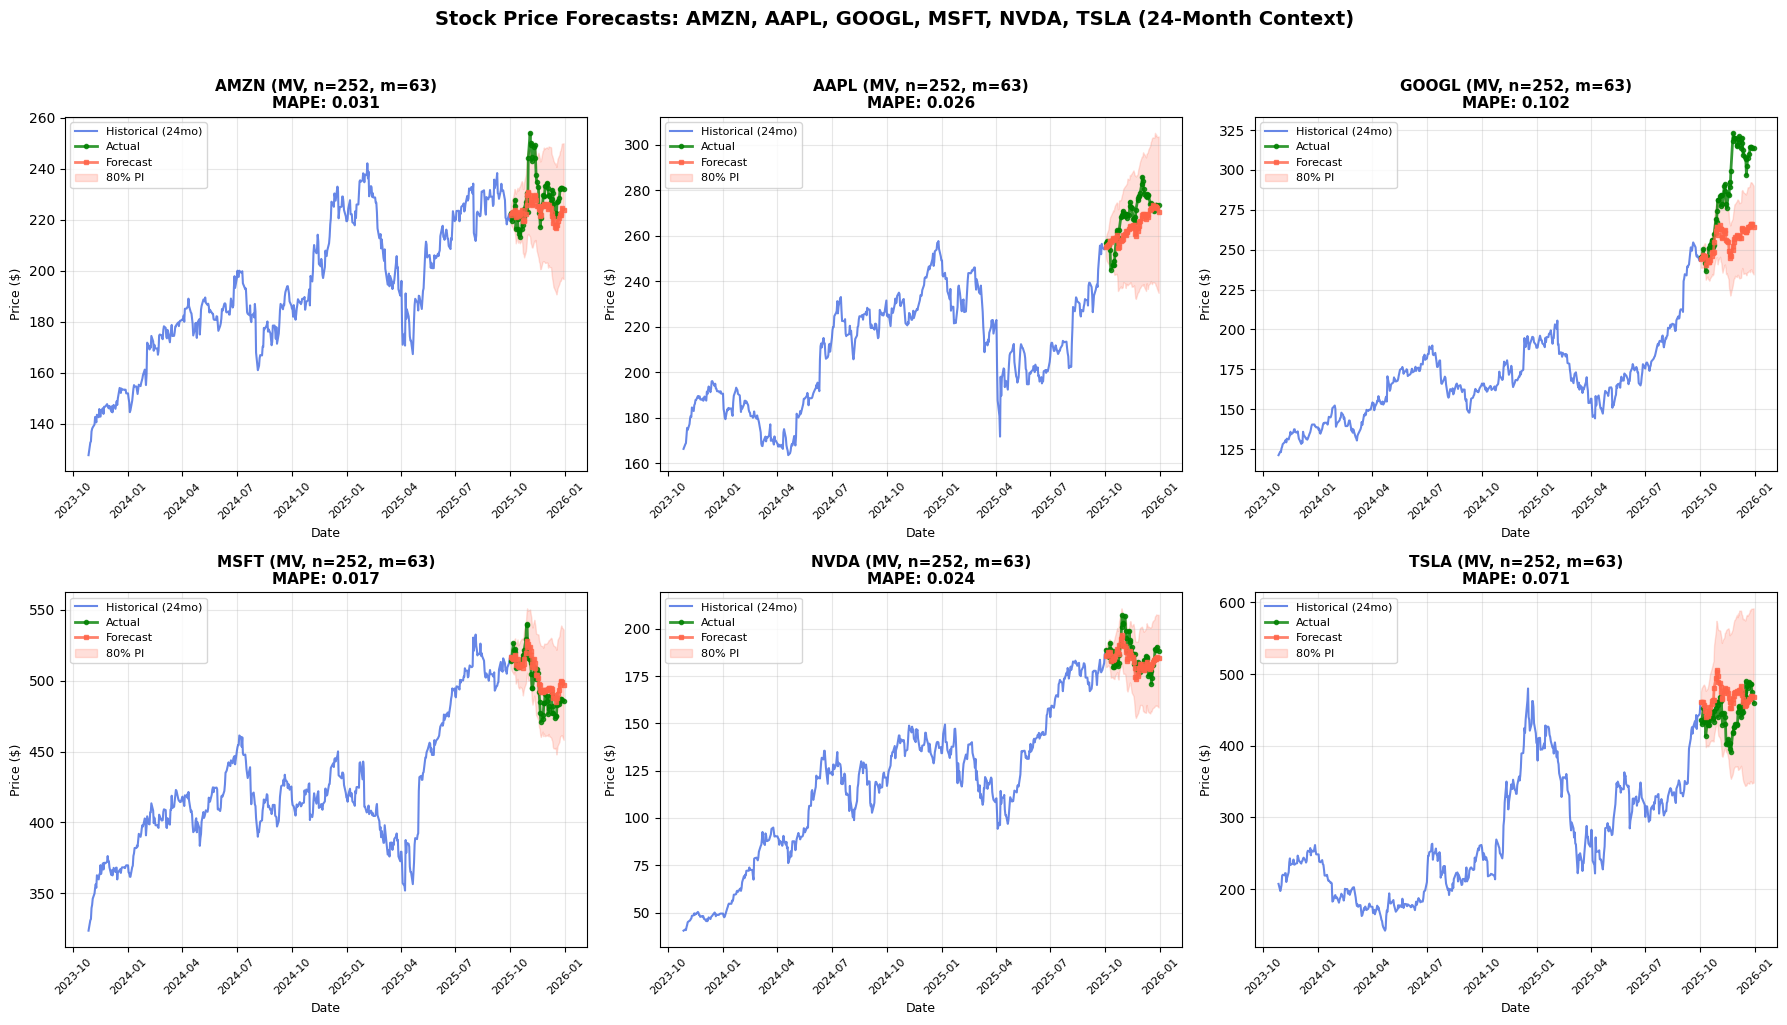

✅ Selected stock forecasts (24-month view) saved as 'selected_stocks_forecasts_24mo.png'


In [ ]:
import ast
import re # Import the regular expression module
from datetime import datetime # Import datetime class

# Define helper function to parse the datetime strings
def parse_datetimestr_list(dt_list_str):
    # First, extract individual datetime strings from the list representation
    # e.g., "datetime.datetime(2025, 12, 2, 0, 0)"
    datetime_entry_strings = re.findall(r'datetime\.datetime\(.*?\)', dt_list_str)

    parsed_dates = []
    # Regex for parsing individual datetime entries
    # Captures (Y, M, D) (Group 1-3), then optionally (H, M) (Group 4-5), then optionally (S) (Group 6)
    entry_regex = re.compile(r'(\d{4}), (\d{1,2}), (\d{1,2})(?:, (\d{1,2}), (\d{1,2})(?:, (\d{1,2}))?)?')

    for entry_str in datetime_entry_strings:
        match = entry_regex.search(entry_str)
        if match:
            year, month, day = int(match.group(1)), int(match.group(2)), int(match.group(3))

            # Safely get hour, minute, second, defaulting to 0 if not present
            hour = int(match.group(4)) if match.group(4) else 0
            minute = int(match.group(5)) if match.group(5) else 0
            second = int(match.group(6)) if match.group(6) else 0 # Group 6 is for seconds

            parsed_dates.append(datetime(year, month, day, hour, minute, second))
    return parsed_dates

### 6. Single Forecast Snapshots for Magnificent-7 Stocks (24-Month View)
## Excluding NFLX and GOOGL

# List of stock tickers (excluding NFLX and GOOGL)
stock_tickers = ["AMZN", "AAPL", "GOOGL", "MSFT", "NVDA", "TSLA"]

# Create a grid of subplots (2 rows x 3 columns, with 1 empty spot)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, ticker in enumerate(stock_tickers):
    # Get the most recent forecast for this stock
    stock_forecasts = forecasts_df[
        (forecasts_df['Dataset'] == 'Stocks') &
        (forecasts_df['Series'] == ticker) &
        (forecasts_df['n'] == 252) &
        (forecasts_df['m'] == 63) &
        (forecasts_df['Mode'] == 'MV')
    ]

    if len(stock_forecasts) == 0:
        axes[idx].text(0.5, 0.5, f'No data for {ticker}',
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{ticker}: No Data Available')
        continue

    # Get the last forecast
    example = stock_forecasts.iloc[-1]

    # Get 24 months of historical context (504 business days)
    forecast_date = example['Date']
    context_data = stocks_df[stocks_df['Date'] <= forecast_date].tail(504)

    # Plot historical data
    axes[idx].plot(context_data['Date'], context_data[ticker],
                  color='royalblue', linewidth=1.5, label='Historical (24mo)', alpha=0.8)

    # Plot actual future values
    forecast_dates = pd.to_datetime(parse_datetimestr_list(example['forecast_dates']))
    actual_values = ast.literal_eval(example['actual_values'])
    axes[idx].plot(forecast_dates, actual_values,
                  color='green', linewidth=2, marker='o', markersize=3,
                  label='Actual', alpha=0.8)

    # Plot predicted values
    predicted_values = ast.literal_eval(example['predicted_values'])
    axes[idx].plot(forecast_dates, predicted_values,
                  color='tomato', linewidth=2, marker='s', markersize=3,
                  label='Forecast', alpha=0.8)

    # Plot prediction interval
    q10 = ast.literal_eval(example['quantile_10'])
    q90 = ast.literal_eval(example['quantile_90'])
    axes[idx].fill_between(forecast_dates, q10, q90,
                          color='tomato', alpha=0.2,
                          label='80% PI')

    # Calculate MAPE for this forecast
    mape = np.mean(np.abs((np.array(actual_values) - np.array(predicted_values)) / np.abs(np.array(actual_values))))

    axes[idx].set_title(f'{ticker} (MV, n=252, m=63)\nMAPE: {mape:.3f}',
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Date', fontsize=9)
    axes[idx].set_ylabel('Price ($)', fontsize=9)
    axes[idx].legend(fontsize=8, loc='best')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)

# Hide the last empty subplot
# axes[5].axis('off')

plt.suptitle('Stock Price Forecasts: AMZN, AAPL, GOOGL, MSFT, NVDA, TSLA (24-Month Context)',
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('selected_stocks_forecasts_24mo.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Selected stock forecasts (24-month view) saved as 'selected_stocks_forecasts_24mo.png'")